In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import copy

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import math
from PIL import Image

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng: {device}")

Đang sử dụng: cpu


In [41]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),    
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.ColorJitter(brightness=0.2),  
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(256),      
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [42]:
try:
    path = r"C:\Users\jason\OneDrive\Documents\Indoor vs Outdoor"
    full_dataset = datasets.ImageFolder(root=path, transform=test_transform)
    
    # Chia 80% train, 20% test
    train_size = int(0.8 * len(full_dataset))
    test_size = len(full_dataset) - train_size
    train_data, test_data = random_split(full_dataset, [train_size, test_size])

    # Áp dụng Augmentation riêng cho train
    train_data.dataset = copy.copy(full_dataset)
    train_data.dataset.transform = train_transform

    trainloader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=0)
    testloader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=0)
    
    num_classes = len(full_dataset.classes)
    print(f"Đã sẵn sàng với Domain: {full_dataset.classes}")
except Exception as e:
    print(f"Lỗi: {e}"); exit()

Đã sẵn sàng với Domain: ['Indoor', 'Outdoor']


In [43]:
class CNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(CNN, self).__init__()
        
        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels, 256, kernel_size=3, padding=1), 
            nn.BatchNorm2d(256),                                   
            nn.LeakyReLU(0.1),                                     
            nn.MaxPool2d(kernel_size=2, stride=2)                  
        )
        
        self.fcn = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 128),                           
            nn.LayerNorm(128),                                     
            nn.LeakyReLU(0.1),
            nn.Dropout(p=0.5),                                     
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.cnn(x)
        x = self.fcn(x)
        return x

In [44]:
def get_model(num_classes):
    base_model = models.mobilenet_v2(pretrained=True)
    
    for param in base_model.parameters():
        param.requires_grad = False
        
    class FullModel(nn.Module):
        def __init__(self, features, num_classes):
            super().__init__()
            self.features = features 
            self.custom_head = CNN(1280, num_classes) 
            
        def forward(self, x):
            x = self.features(x) 
            x = self.custom_head(x)
            return x
            
    return FullModel(base_model.features, num_classes)

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_model(num_classes).to(device)
optimizer = optim.Adam(model.custom_head.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print("Bắt đầu huấn luyện trên domain mới...")
for epoch in range(5):
    model.train()
    total_loss = 0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            out = model(images)
            correct += (out.argmax(1) == labels).sum().item()
    
    print(f"Epoch {epoch+1} | Loss: {total_loss/len(trainloader):.4f} | Test Acc: {100*correct/len(test_data):.2f}%")

Bắt đầu huấn luyện trên domain mới...
Epoch 1 | Loss: 0.0813 | Test Acc: 99.10%
Epoch 2 | Loss: 0.0546 | Test Acc: 98.58%
Epoch 3 | Loss: 0.0468 | Test Acc: 99.22%
Epoch 4 | Loss: 0.0419 | Test Acc: 99.33%
Epoch 5 | Loss: 0.0390 | Test Acc: 99.53%



--- DỰ BÁO MỘT VÀI KẾT QUẢ ---


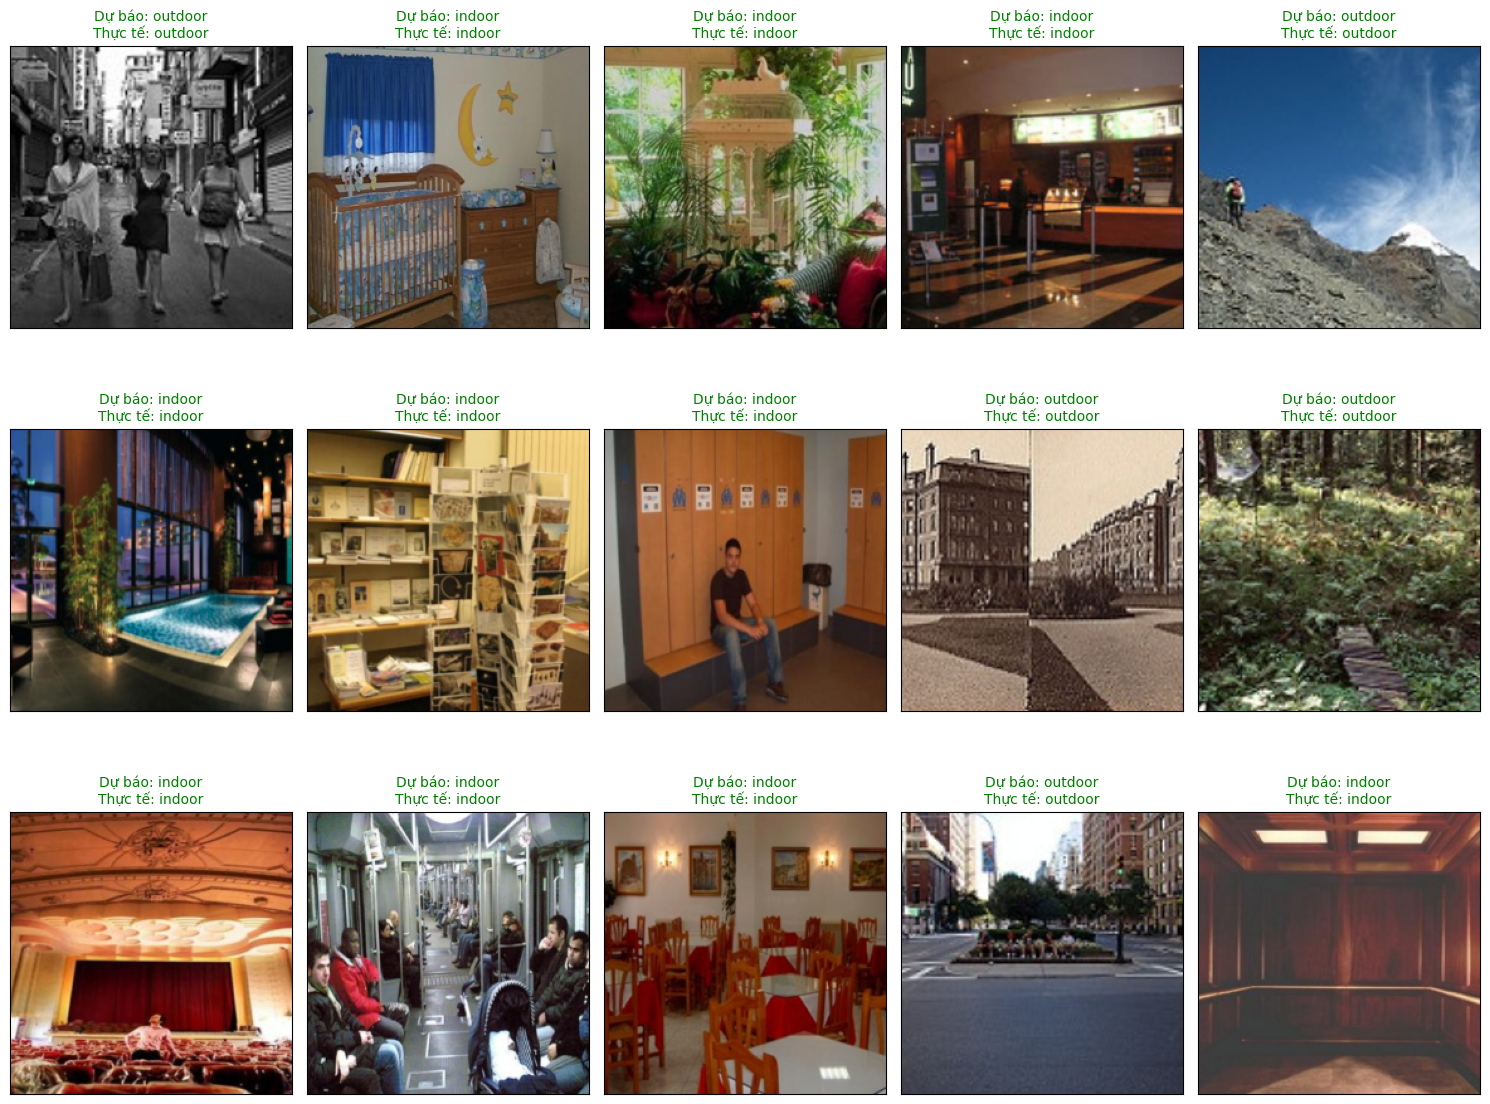

In [56]:
model.eval()
classes = ['indoor', 'outdoor']

print("\n--- DỰ BÁO MỘT VÀI KẾT QUẢ ---")

dataiter = iter(testloader)
images, labels = next(dataiter)

device = next(model.parameters()).device
images_device = images.to(device)

with torch.no_grad():
    outputs = model(images_device)
    _, predicted = torch.max(outputs, 1)

num_samples = 15
num_cols = 5
num_rows = math.ceil(num_samples / num_cols)
fig = plt.figure(figsize=(15, 4 * num_rows))

for i in range(num_samples):
    true_idx = labels[i].item()
    pred_idx = predicted[i].item()
    
    true_label = classes[true_idx]
    pred_label = classes[pred_idx]
    status = "ĐÚNG" if true_idx == pred_idx else "SAI"
    
    ax = fig.add_subplot(num_rows, num_cols, i+1, xticks=[], yticks=[])
    
    img_display = images[i].cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_display = std * img_display + mean
    img_display = np.clip(img_display, 0, 1)
    
    plt.imshow(img_display)
    
    title_color = "green" if status == "ĐÚNG" else "red"
    ax.set_title(f"Dự báo: {pred_label}\nThực tế: {true_label}", color=title_color, fontsize=10)

plt.tight_layout()
plt.show()